In [1]:
from google.colab import drive

drive.mount('/content/drive')

%cd /content/drive/MyDrive/faster_rcnn
%cp VOC2007.zip /content
%cp VOC2012.zip /content
%cd /content

drive.flush_and_unmount()

Mounted at /content/drive
/content/drive/MyDrive/faster_rcnn
/content


In [1]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

In [2]:
from src.backbone import backbone_transform

transform = backbone_transform

In [3]:
from src.dataset import get_voc_img_paths_train, get_voc_img_paths_test, create_voc_dataloader

voc2007_img_paths_train, voc2012_img_paths_train = get_voc_img_paths_train()
voc2007_img_paths_test, voc2012_img_paths_test = get_voc_img_paths_test()

train_dataloader = create_voc_dataloader(img_paths_list=voc2007_img_paths_train, transform=transform, batch_size=32, shuffle=True)
dataset = train_dataloader.dataset

In [4]:
batch_imgs, batch_gt_boxes, batch_gt_labels, batch_img_sizes_before_pad = next(iter(train_dataloader))
batch_imgs.shape, batch_gt_boxes[0], batch_gt_labels[0], batch_img_sizes_before_pad[0]

(torch.Size([32, 3, 1000, 929]),
 tensor([[624.3243, 247.2000, 856.7568, 332.4000],
         [805.4054, 218.4000, 900.0000, 313.2000],
         [348.6487, 264.0000, 864.8649, 570.0000]]),
 tensor([19, 19, 14]),
 (600, 900))

In [5]:
batch_gt_boxes

[tensor([[624.3243, 247.2000, 856.7568, 332.4000],
         [805.4054, 218.4000, 900.0000, 313.2000],
         [348.6487, 264.0000, 864.8649, 570.0000]]),
 tensor([[302.4000,  12.8000, 500.4000, 565.3333],
         [  1.2000,   4.2667, 252.0000, 627.2000],
         [141.6000, 113.0667, 434.4000, 755.2000]]),
 tensor([[ 98.1333, 226.8000, 317.8667, 566.4000],
         [482.1333, 243.6000, 693.3333, 573.6000]]),
 tensor([[266.4000, 356.2667, 297.6000, 398.9333]]),
 tensor([[299.6774, 138.7500, 710.2355, 523.7500],
         [254.7258,  92.5000, 719.2258, 327.5000]]),
 tensor([[124.8000,  67.0410, 535.2000, 769.0000],
         [ 81.6000, 384.5000, 145.2000, 567.8770]]),
 tensor([[188.4000, 378.9594, 448.8000, 649.9594],
         [141.6000, 356.9268, 372.0000, 683.0081]]),
 tensor([[  3.6000,   8.5333, 338.4000, 795.7333],
         [232.8000, 219.7333, 513.6000, 800.0000]]),
 tensor([[  1.2000, 302.9333, 196.8000, 791.4667],
         [106.8000, 192.0000, 212.4000, 516.2667],
         [290.4

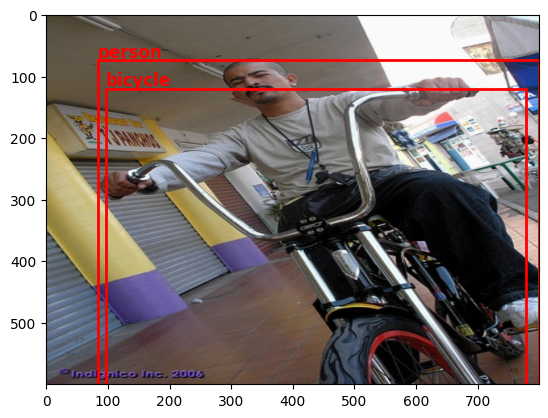

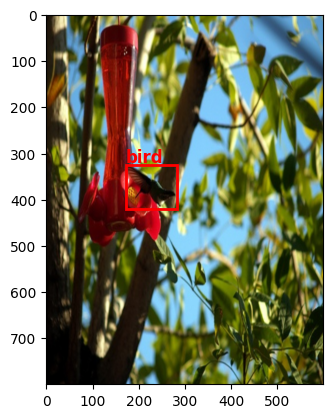

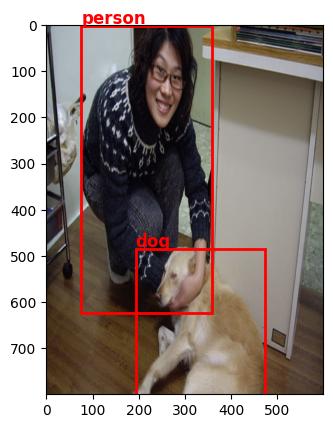

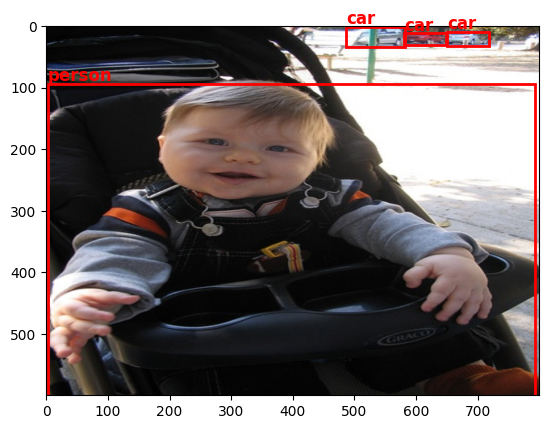

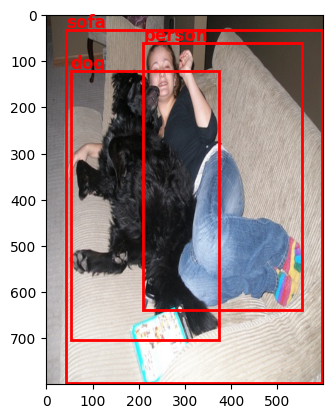

In [6]:
from src.utils import display_random_images_with_annotations, plot_image_with_annotations

display_random_images_with_annotations(dataset)

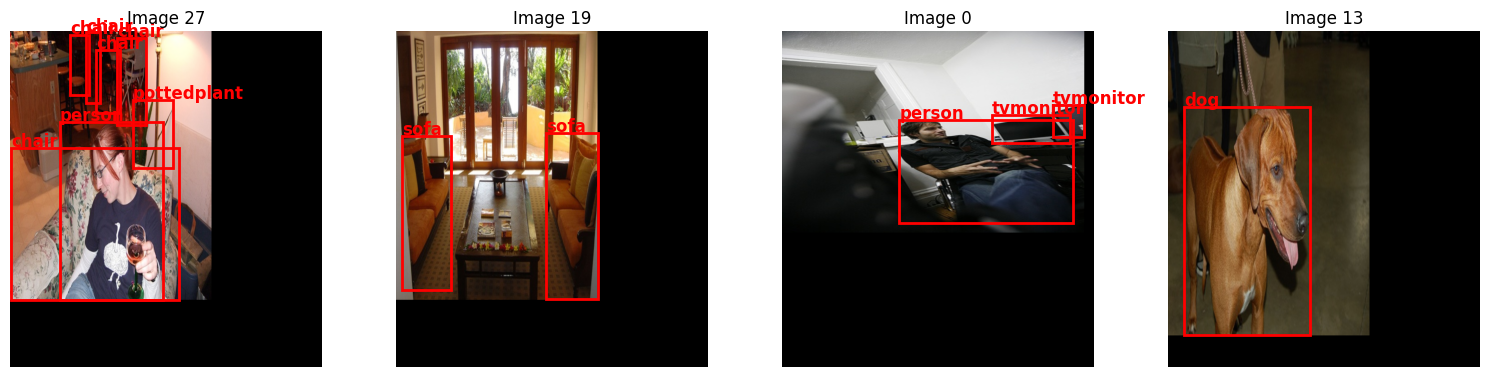

In [7]:
from src.utils import display_random_batch_images
display_random_batch_images(batch_imgs, batch_gt_labels, batch_gt_boxes, num_images=4)

In [8]:
from src.backbone import Backbone
import torch

backbone = Backbone()

backbone.eval()  # Set the backbone to evaluation mode

backbone.to(device)  # Move the backbone to the appropriate device
batch_imgs = batch_imgs.to(device)
with torch.inference_mode():
    output = backbone(batch_imgs)
    print(f"Backbone output shape: {output.shape}")
    

Backbone output shape: torch.Size([32, 1024, 63, 59])


In [9]:
import torch
scales = torch.tensor([128, 256, 512])
ratios = torch.tensor([0.5, 1, 2])

widths = scales.view(-1, 1) * torch.sqrt(ratios).view(1, -1)
heights = scales.view(-1, 1) / torch.sqrt(ratios).view(1, -1)

widths.shape, heights.shape, torch.stack((widths.flatten(), heights.flatten()), dim=-1)[None, None, : ].shape  # This will give you the width and height pairs for each scale and ratio combination

(torch.Size([3, 3]), torch.Size([3, 3]), torch.Size([1, 1, 9, 2]))

In [10]:
import torch
import torch.nn as nn

class RPN_Head(nn.Module):
    def __init__(self, in_channels, mid_channels):
        super(RPN_Head, self).__init__()
        self.num_anchors = 9
        self.conv1 = nn.Conv2d(in_channels, mid_channels, kernel_size=3, stride=1, padding=1)
        self.conv_cls = nn.Conv2d(mid_channels, self.num_anchors * 2, kernel_size=1, stride=1)
        self.conv_reg = nn.Conv2d(mid_channels, self.num_anchors * 4, kernel_size=1, stride=1)


        self.conv1.weight.data.normal_(0, 0.01)
        self.conv_cls.weight.data.normal_(0, 0.01)
        self.conv_reg.weight.data.normal_(0, 0.01)
        self.conv1.bias.data.zero_()
        self.conv_cls.bias.data.zero_()
        self.conv_reg.bias.data.zero_()

        self.scales = torch.tensor([128, 256, 512])
        self.ratios = torch.tensor([0.5, 1, 2])

    def forward(self, feature_map, batch_img_height=None, batch_img_width=None):
        self.img_height = batch_img_height
        self.img_width = batch_img_width

        x = torch.relu(self.conv1(feature_map))
        batch_cls_logits = self.conv_cls(x).permute(0, 2, 3, 1)
        batch_box_deltas = self.conv_reg(x).permute(0, 2, 3, 1)

        batch_cls_logits = batch_cls_logits.reshape(batch_cls_logits.shape[0], -1, 2)
        batch_box_deltas = batch_box_deltas.reshape(batch_box_deltas.shape[0], -1, 4)

        batch_anchors = self.generate_anchors(feature_map)

        return batch_cls_logits, batch_box_deltas, batch_anchors

    # Generates anchors : [batch_size, num_anchors_total, 4] where 4 corresponds to (x_c, y_c, width, height)
    def generate_anchors(self, feature_map):
        # This function should generate anchors based on the feature map size and predefined scales/aspect ratios

        batch_size, _, width, height = feature_map.shape

        # Calculating stride for the feature map relative to the input image
        total_stride_x = self.img_height // height   
        total_stride_y = self.img_width // width    

        # For each position in the feature map, calculate the center of the anchor box
        # center_x = (x_coord * total_stride_x) + (0.5 * total_stride_x)
        # center_y = (y_coord * total_stride_y) + (0.5 * total_stride_y)

        # Create a grid of center positions
        grid_x = torch.arange(width).float() + 0.5
        grid_y = torch.arange(height).float() + 0.5

        # Create a meshgrid of x_center, y_center positions for each anchor for each value of width and height in feature map
        grid_x, grid_y = torch.meshgrid(grid_x, grid_y, indexing='ij')

        # Converting grid positions to the scale from the feature map to the image size
        grid_x = grid_x * total_stride_x
        grid_y = grid_y * total_stride_y

        # Now, for each center position, we need to generate anchors based on the scales and aspect ratios
        widths = self.scales.view(-1, 1) * torch.sqrt(self.ratios).view(1, -1)
        heights = self.scales.view(-1, 1) / torch.sqrt(self.ratios).view(1, -1)


        centres = torch.stack((grid_x, grid_y), dim=-1).unsqueeze(dim=-2)  # Shape: [height, width, 1, 2]
        sizes = torch.stack((widths.flatten(), heights.flatten()), dim=-1)[None, None, : ]  # Shape: [1, 1, num_scales * num_ratios, 2]

        anchors = torch.cat((centres.expand(-1, -1, sizes.shape[2], -1), sizes.expand(centres.shape[0], centres.shape[1], -1, -1)), dim=-1)  # Shape: [height, width, num_anchors, 4]
        anchors = anchors.view(-1, 4)  # Flatten to [num_anchors_total, 4]
        
        batch_anchors = anchors.repeat(batch_size, 1, 1)  # Repeat for each image in the batch
        batch_anchors = batch_anchors.to(feature_map.device)  # Move to the same device as the feature map
        
        return batch_anchors 
           

In [11]:
test = RPN_Head(in_channels=1024, mid_channels=512)
print(batch_imgs.shape)

with torch.inference_mode():
    test.eval()
    test.to(device)

    batch_cls_logits, batch_box_deltas, batch_anchors = test.forward(output, batch_img_height=batch_imgs[0].shape[1], batch_img_width=batch_imgs[0].shape[2])  # Simulated original image sizes for the batch
    print(f"RPN cls logits shape: {batch_cls_logits.shape}, RPN reg preds shape: {batch_box_deltas.shape}")
    print(f"RPN anchors shape: {batch_anchors.shape}")



torch.Size([32, 3, 1000, 929])
RPN cls logits shape: torch.Size([32, 33453, 2]), RPN reg preds shape: torch.Size([32, 33453, 4])
RPN anchors shape: torch.Size([32, 33453, 4])


In [12]:
def compute_iou_matrix(anchors, gt_box):
        # Compute the IoU matrix between anchors and ground truth boxes
        # anchors: [num_anchors, 4], gt_boxes: [num_gt_boxes, 4]
        # Returns: IoU matrix of shape [num_anchors, num_gt_boxes]


        # Convert anchors and gt_boxes to (x1, y1, x2, y2) format
        anchor_x1 = anchors[:, 0] - anchors[:, 2] / 2
        anchor_y1 = anchors[:, 1] - anchors[:, 3] / 2
        anchor_x2 = anchors[:, 0] + anchors[:, 2] / 2
        anchor_y2 = anchors[:, 1] + anchors[:, 3] / 2
        print(f"Shapes {anchor_x1.shape}, {anchor_y1.shape}, {anchor_x2.shape}, {anchor_y2.shape}")
        
        gt_x1 = gt_boxes[:, 0]
        gt_y1 = gt_boxes[:, 1]
        gt_x2 = gt_boxes[:, 2]
        gt_y2 = gt_boxes[:, 3]
        print(f"Shapes {gt_x1.shape}, {gt_y1.shape}, {gt_x2.shape}, {gt_y2.shape}")
        print(anchors.device, gt_boxes.device, anchor_x1.device, gt_x1.device)
        
        # Calculate intersection
        inter_x1 = torch.max(anchor_x1.unsqueeze(1), gt_x1.unsqueeze(0))                # Unsqueeze to align dimensions for broadcasting
        inter_y1 = torch.max(anchor_y1.unsqueeze(1), gt_y1.unsqueeze(0))
        inter_x2 = torch.min(anchor_x2.unsqueeze(1), gt_x2.unsqueeze(0))
        inter_y2 = torch.min(anchor_y2.unsqueeze(1), gt_y2.unsqueeze(0))
        print(f"Shapes {inter_x1.shape}, {inter_y1.shape}, {inter_x2.shape}, {inter_y2.shape}")

        

        inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)
        print(inter_area.shape)
        
        # Calculate union
        anchor_area = (anchor_x2 - anchor_x1) * (anchor_y2 - anchor_y1)
        gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)

        print(f"Shapes {anchor_area.shape}, {gt_area.shape}")
        
        union_area = anchor_area.unsqueeze(dim=1) + gt_area.unsqueeze(dim=0) - inter_area       # unsqueeze to align dimensions for broadcasting
        
        # Compute IoU
        iou_matrix = inter_area / union_area
        
        return iou_matrix

anchors = batch_anchors[0]  # Assuming batch_anchors is the output from RPN_Head's forward method
gt_boxes = batch_gt_boxes[0]  # Ensure batch_gt_boxes is on the same device as anchors
gt_boxes = gt_boxes.to(anchors.device)  # Move gt_boxes to the same device as anchors
iou_matrix = compute_iou_matrix(anchors, gt_boxes)

Shapes torch.Size([33453]), torch.Size([33453]), torch.Size([33453]), torch.Size([33453])
Shapes torch.Size([3]), torch.Size([3]), torch.Size([3]), torch.Size([3])
cuda:0 cuda:0 cuda:0 cuda:0
Shapes torch.Size([33453, 3]), torch.Size([33453, 3]), torch.Size([33453, 3]), torch.Size([33453, 3])
torch.Size([33453, 3])
Shapes torch.Size([33453]), torch.Size([3])


In [13]:
class RPN_Loss(nn.Module):
    def __init__(self):
        super(RPN_Loss, self).__init__()
        self.cls_loss_fn = nn.CrossEntropyLoss()
        self.reg_loss_fn = nn.SmoothL1Loss()

    def forward(self, batch_cls_logits, batch_box_deltas, batch_anchors, batch_gt_boxes, img_sizes_before_pad):
        batch_size = batch_cls_logits.shape[0]

        total_cls_loss = 0.0
        total_reg_loss = 0.0

        for i in range(batch_size):
            img_height, img_width = img_sizes_before_pad[i]

            cls_logits = batch_cls_logits[i]
            box_deltas = batch_box_deltas[i]
            anchors = batch_anchors[i]

            gt_boxes = batch_gt_boxes[i]
            gt_boxes = gt_boxes.to(anchors.device)  # Move gt_boxes to the same device as anchors

            inside_indices = self.anchors_inside_image(anchors, img_height, img_width)

            anchors = anchors[inside_indices]
            cls_logits = cls_logits[inside_indices]
            box_deltas = box_deltas[inside_indices]

            anchor_labels, matched_gt_indices = self.anchor_labelling(anchors, gt_boxes)

            sample_mask, sampled_pos_idx, sampled_neg_idx = self.create_sample_mask_per_img(anchor_labels)

            cls_loss = self.cls_loss_fn_per_img(cls_logits, anchor_labels, sample_mask)
            reg_loss = self.reg_loss_fn_per_img(box_deltas, gt_boxes, anchors, sampled_pos_idx, matched_gt_indices)  # Assuming gt_boxes are the regression targets

            total_cls_loss += cls_loss
            total_reg_loss += reg_loss

        return total_cls_loss / batch_size, total_reg_loss / batch_size  # Return average losses over the batch


    def cls_loss_fn_per_img(self, cls_logits, anchor_labels, sample_mask):
        selected_cls_logits = cls_logits[sample_mask]
        selected_anchor_labels = anchor_labels[sample_mask]

        targets = (selected_anchor_labels == 1).long()  # Convert to binary targets (1 for positive, 0 for negative)

        cls_loss = nn.functional.cross_entropy(selected_cls_logits, targets, reduction='mean')      # reduction='mean' to get the average loss over the selected samples i.e., divide by num_samples = Ncls
        return cls_loss
    
    def corners_to_center(self, boxes):
        x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
        w = x2 - x1
        h = y2 - y1
        x_c = x1 + w / 2
        y_c = y1 + h / 2
        return torch.stack([x_c, y_c, w, h], dim=1)


    def reg_loss_fn_per_img(self, box_deltas, gt_boxes, valid_anchors, sampled_pos_idx, matched_gt_indices):
        pred_box_deltas = box_deltas[sampled_pos_idx]
        selected_gt_boxes = gt_boxes[matched_gt_indices[sampled_pos_idx]]  # Select the corresponding gt_boxes for the sampled positive anchors
        anchors = valid_anchors[sampled_pos_idx]

        gt_boxes_centered = self.corners_to_center(selected_gt_boxes)

        xc_a, yc_a, w_a, h_a = anchors[:, 0], anchors[:, 1], anchors[:, 2], anchors[:, 3]
        gt_xc, gt_yc, gt_w, gt_h = gt_boxes_centered[:, 0], gt_boxes_centered[:, 1], gt_boxes_centered[:, 2], gt_boxes_centered[:, 3]

        # Calculate the regression targets (deltas) for the selected anchors
        target_dx = (gt_xc - xc_a) / w_a
        target_dy = (gt_yc - yc_a) / h_a
        target_dw = torch.log(gt_w / w_a)
        target_dh = torch.log(gt_h / h_a)

        target_box_deltas = torch.stack((target_dx, target_dy, target_dw, target_dh), dim=1)

        reg_loss = nn.functional.smooth_l1_loss(pred_box_deltas, target_box_deltas, reduction='mean')      # reduction='mean' to get the average loss over the selected samples i.e., divide by num_samples = Nreg
        return reg_loss

    def create_sample_mask_per_img(self, anchor_labels, num_samples=256, pos_fraction=0.5):
        positive_idx = torch.where(anchor_labels == 1)[0]       # ...[0] as it is a single valued tuple
        negative_idx = torch.where(anchor_labels == -1)[0]

        num_pos = min(int(num_samples * pos_fraction), positive_idx.numel())    # numel() returns the number of elements in the tensor
        num_neg = min(num_samples - num_pos, negative_idx.numel())

        perm_pos = torch.randperm(positive_idx.numel(), device=anchor_labels.device)[:num_pos]
        perm_neg = torch.randperm(negative_idx.numel(), device=anchor_labels.device)[:num_neg]

        sampled_pos_idx = positive_idx[perm_pos]
        sampled_neg_idx = negative_idx[perm_neg]

        # Ignoring i.e., making the anchor labels of the unsampled anchors to 0 (ignore)
        sample_mask = torch.zeros_like(anchor_labels, dtype=torch.bool, device=anchor_labels.device)
        sample_mask[sampled_pos_idx] = True
        sample_mask[sampled_neg_idx] = True

        return sample_mask, sampled_pos_idx, sampled_neg_idx

    def anchor_labelling(self, anchors, gt_boxes, pos_iou_threshold=0.7, neg_iou_threshold=0.3):
        iou_matrix = self.compute_iou_matrix(anchors, gt_boxes)

        num_anchors, num_gt_boxes = iou_matrix.shape
        labels = torch.zeros((num_anchors,), dtype=torch.long, device=anchors.device)  # Initialize all labels to 0 (ignore)

        max_iou_per_anchor, matched_gt_indices = iou_matrix.max(dim=1)

        labels[max_iou_per_anchor < neg_iou_threshold] = -1  # Negative labels
        labels[max_iou_per_anchor >= pos_iou_threshold] = 1  # Positive labels

        max_iou_per_gt, matched_anchor_indices = iou_matrix.max(dim=0)

        labels[matched_anchor_indices] = 1  # Ensure each gt box has at least one positive anchor

        return labels, matched_gt_indices

    def anchors_inside_image(self, anchors, img_height, img_width):
        # Check if anchors are inside the image boundaries
        xc, yc, w, h = anchors[:, 0], anchors[:, 1], anchors[:, 2], anchors[:, 3]

        x1 = xc - w / 2
        y1 = yc - h / 2
        x2 = xc + w / 2
        y2 = yc + h / 2

        inside_indices = (0<=x1) & (0<=y1) & (x2 < img_width) & (y2 < img_height)           # anchors[:, 0] is xc, anchors[:, 1] is yc, anchors[:, 2] is h, anchors[:, 3] is w
        return inside_indices
    
    def compute_iou_matrix(self, anchors, gt_boxes):
        # Compute the IoU matrix between anchors and ground truth boxes
        # anchors: [num_anchors, 4], gt_boxes: [num_gt_boxes, 4]
        # Returns: IoU matrix of shape [num_anchors, num_gt_boxes]
        
        # Convert anchors and gt_boxes to (x1, y1, x2, y2) format
        anchor_x1 = anchors[:, 0] - anchors[:, 2] / 2
        anchor_y1 = anchors[:, 1] - anchors[:, 3] / 2
        anchor_x2 = anchors[:, 0] + anchors[:, 2] / 2
        anchor_y2 = anchors[:, 1] + anchors[:, 3] / 2
        
        gt_x1 = gt_boxes[:, 0]
        gt_y1 = gt_boxes[:, 1]
        gt_x2 = gt_boxes[:, 2]
        gt_y2 = gt_boxes[:, 3]
        
        # Calculate intersection
        inter_x1 = torch.max(anchor_x1.unsqueeze(1), gt_x1.unsqueeze(0))        # Unsqueeze to align dimensions for broadcasting
        inter_y1 = torch.max(anchor_y1.unsqueeze(1), gt_y1.unsqueeze(0))
        inter_x2 = torch.min(anchor_x2.unsqueeze(1), gt_x2.unsqueeze(0))
        inter_y2 = torch.min(anchor_y2.unsqueeze(1), gt_y2.unsqueeze(0))
        
        inter_area = torch.clamp(inter_x2 - inter_x1, min=0) * torch.clamp(inter_y2 - inter_y1, min=0)
        
        # Calculate union
        anchor_area = (anchor_x2 - anchor_x1) * (anchor_y2 - anchor_y1)
        gt_area = (gt_x2 - gt_x1) * (gt_y2 - gt_y1)
        
        union_area = anchor_area.unsqueeze(dim=1) + gt_area.unsqueeze(dim=0) - inter_area           # Unsqueeze to align dimensions for broadcasting
        
        # Compute IoU
        iou_matrix = inter_area / union_area
        
        return iou_matrix


In [17]:
loss_criterion = RPN_Loss()

loss = loss_criterion(batch_cls_logits=batch_cls_logits, 
                      batch_box_deltas=batch_box_deltas, 
                      batch_anchors=batch_anchors, 
                      batch_gt_boxes=batch_gt_boxes, 
                      img_sizes_before_pad=batch_img_sizes_before_pad)

loss

AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
import torchvision.ops as ops

class RegionProposalNetwork(nn.Module):
    def __init__(self, in_channels, mid_channels, pre_nms_top_n=6000, post_nms_top_n=300, nms_iou_threshold=0.7):
        super(RegionProposalNetwork, self).__init__()
        self.rpn_head = RPN_Head(in_channels, mid_channels)
        self.pre_nms_top_n = pre_nms_top_n
        self.post_nms_top_n = post_nms_top_n
        self.nms_iou_threshold = nms_iou_threshold

    def forward(self, feature_map, batch_img_height=None,  batch_img_width=None, img_sizes_before_pad=None):
        batch_cls_logits, batch_box_deltas, batch_anchors = self.rpn_head(feature_map, batch_img_height=batch_img_height, batch_img_width=batch_img_width)
        print(batch_cls_logits.shape, batch_box_deltas.shape, batch_anchors.shape)

        batch_size = batch_cls_logits.shape[0]

        scores_list = []
        boxes_list = []

        for i in range(batch_size):
            img_height, img_width = img_sizes_before_pad[i]

            cls_logits = batch_cls_logits[i]
            box_deltas = batch_box_deltas[i]
            anchors = batch_anchors[i]

            scores = nn.functional.softmax(cls_logits, dim=-1)[:, 1]  # Get the foreground class scores for each box
            print(f"Scores shape: {scores.shape}")

            decoded_boxes = self.decode_box_deltas(anchors, box_deltas)

            clipped_boxes = self.clip_boxes_to_image(decoded_boxes, img_height, img_width)

            filtered_boxes = self.filter_small_boxes(scores, clipped_boxes, min_size=16)
            print(f"Filtered boxes shape: {filtered_boxes.shape}")

            print(decoded_boxes.device, anchors.device, box_deltas.device)

            pre_nms_top_n_boxes, pre_nms_top_n_scores = self.pre_nms_top_n(filtered_boxes, scores, pre_nms_top_n=6000)

            post_nms_indices = self.nms(pre_nms_top_n_boxes, pre_nms_top_n_scores, iou_threshold=0.7)

            post_nms_top_n_boxes, post_nms_top_n_scores = self.post_nms_top_n(pre_nms_top_n_boxes, pre_nms_top_n_scores, post_nms_indices, post_nms_top_n=300)

            scores_list.append(post_nms_top_n_scores)
            boxes_list.append(post_nms_top_n_boxes)

        return scores_list, boxes_list

    # Decoding box deltas to get the final bounding boxes per img
    def decode_box_deltas(self, anchors, box_deltas):
        # Decode the predicted box deltas to get the final bounding boxes
        # anchors: [num_anchors, 4], box_deltas: [num_anchors, 4]
        # Returns: decoded_boxes of shape [num_anchors, 4]

        xc_a, yc_a, w_a, h_a = anchors[:, 0], anchors[:, 1], anchors[:, 2], anchors[:, 3]
        dx, dy, dw, dh = box_deltas[:, 0], box_deltas[:, 1], box_deltas[:, 2], box_deltas[:, 3]

        # Apply the inverse of the encoding transformation
        xc = dx * w_a + xc_a
        yc = dy * h_a + yc_a
        w = torch.exp(dw) * w_a
        h = torch.exp(dh) * h_a

        # Convert back to (xmin, ymin, xmax, ymax) format
        xmin = xc - w / 2
        ymin = yc - h / 2
        xmax = xc + w / 2
        ymax = yc + h / 2

        decoded_boxes = torch.stack((xmin, ymin, xmax, ymax), dim=1)
        return decoded_boxes
    
    # Clip the decoded boxes to ensure they are within the image boundaries per img
    def clip_boxes_to_image(self, decoded_boxes, img_height, img_width):
        # Clip the decoded boxes to ensure they are within the image boundaries
        # decoded_boxes: [num_anchors, 4]
        # Returns: clipped_boxes of shape [num_anchors, 4]

        xmin = torch.clamp(decoded_boxes[:, 0], min=0, max=img_width - 1)
        ymin = torch.clamp(decoded_boxes[:, 1], min=0, max=img_height - 1)
        xmax = torch.clamp(decoded_boxes[:, 2], min=0, max=img_width - 1)
        ymax = torch.clamp(decoded_boxes[:, 3], min=0, max=img_height - 1)

        clipped_boxes = torch.stack((xmin, ymin, xmax, ymax), dim=1)
        return clipped_boxes
    
    def filter_small_boxes(self, scores, decoded_boxes, min_size=16):
        # Filter out boxes that are smaller than a specified minimum size
        # decoded_boxes: [num_anchors, 4]
        # Returns: filtered_boxes of shape [num_filtered_anchors, 4]

        widths = decoded_boxes[:, 2] - decoded_boxes[:, 0]
        heights = decoded_boxes[:, 3] - decoded_boxes[:, 1]

        keep_indices = (widths >= min_size) & (heights >= min_size)
        filtered_boxes = decoded_boxes[keep_indices]

        # also need to remove the scores corresponding to the filtered boxes, but that will be handled in the pre_nms_top_n function
        filtered_scores = scores[keep_indices]  # Assuming scores is available in the context where this function is called

        return filtered_boxes

    # Get the top N boxes based on their scores before applying NMS per img
    def pre_nms_top_n(self, decoded_boxes, scores):
        # Select the top N boxes based on their scores before applying NMS
        # decoded_boxes: [num_anchors, 4], scores: [num_anchors]
        # Returns: top_decoded_boxes of shape [pre_nms_top_n, 4], top_scores of shape [pre_nms_top_n]

        # scores = nn.functional.softmax(scores, dim=-1)[:1]  # Get the foreground class scores for each box, since 1:obj, 0: background, therefore [:1] gives the foreground class scores for each box

        top_scores, top_indices = torch.topk(scores, k=min(self.pre_nms_top_n, scores.size(0)))
        top_decoded_boxes = decoded_boxes[top_indices]

        return top_decoded_boxes, top_scores
    
    def nms(self, decoded_boxes, scores):
        # Apply Non-Maximum Suppression (NMS) to remove overlapping boxes
        # decoded_boxes: [num_anchors, 4], scores: [num_anchors]
        # Returns: keep_indices of shape [num_kept_anchors]

        keep_indices = ops.nms(decoded_boxes, scores, self.nms_iou_threshold)
        return keep_indices
    
    def post_nms_top_n(self, bboxes, scores, keep_indices):
        # Select the top N boxes after applying NMS
        # decoded_boxes_post_nms: [num_kept_anchors, 4], scores_post_nms: [num_kept_anchors]
        # Returns: final_decoded_boxes of shape [post_nms_top_n, 4], final_scores of shape [post_nms_top_n]

        scores_post_nms = scores[keep_indices]
        boxes_post_nms = bboxes[keep_indices]

        top_scores_post_nms, top_indices_post_nms = torch.topk(scores_post_nms, k=min(self.post_nms_top_n, scores_post_nms.size(0)))
        final_decoded_boxes = boxes_post_nms[top_indices_post_nms]

        return final_decoded_boxes, top_scores_post_nms

    


In [16]:
rpn_network = RegionProposalNetwork(in_channels=1024, mid_channels=512)

print(batch_imgs.shape)

with torch.inference_mode():
    rpn_network.eval()
    rpn_network.to(device)

    batch_scores, batch_boxes = rpn_network(output, batch_img_height=batch_imgs[0].shape[1], batch_img_width=batch_imgs[0].shape[2], img_sizes_before_pad=batch_img_sizes_before_pad)  # Simulated original image sizes for the batch

print(f"RPN scores list length: {len(batch_scores)}, RPN boxes list length: {len(batch_boxes)}")
print(f"RPN scores shape for first image: {batch_scores[0].shape}, RPN boxes shape for first image: {batch_boxes[0].shape}")

torch.Size([32, 3, 1000, 929])
torch.Size([32, 33453, 2]) torch.Size([32, 33453, 4]) torch.Size([32, 33453, 4])
Scores shape: torch.Size([33453])
Filtered boxes shape: torch.Size([28910, 4])
cuda:0 cuda:0 cuda:0


AcceleratorError: CUDA error: device-side assert triggered
Search for `cudaErrorAssert' in https://docs.nvidia.com/cuda/cuda-runtime-api/group__CUDART__TYPES.html for more information.
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
